In [1]:
from matplotlib import pyplot as plt

import numpy as np

from glob import glob
# import os

from py_eddy_tracker.observations.observation import EddiesObservations

from datetime import datetime, timedelta
import matplotlib.dates as mdates


# Loading data:

In [2]:
from pathlib import Path as PathL

# Get the user's home directory
homedir = PathL.home()
# print(f"Home directory: {homedir}")


## Loading MIOST-K v2.0.1:

In [3]:
indir_miost = str(homedir) + "/Nextcloud/Projects/FaSt-SWOT/Data/SWOT/ftp_aviso/swot_products/l4_karin_nadir/v2.0.1/miost/"
indir_miost_s = indir_miost + 'subset/'

In [4]:
data_paths_MIOST_v201_all = sorted(glob(indir_miost_s + "dt_global_allsat_phy_l4_202*_sub.nc"))

In [5]:
data_paths_MIOST_v201 = data_paths_MIOST_v201_all[0:-153] # selecting only till 30/06/2024

In [6]:
len(data_paths_MIOST_v201)

335

In [7]:
indir_eddies = "data/eddy-tracker_outputs/"

In [8]:
data_path  = data_paths_MIOST_v201[19]

In [9]:
a_names_MIOST_v201 = []
c_names_MIOST_v201 = []

for data_path in data_paths_MIOST_v201:
   date = datetime(int(data_path[-15:-11]), int(data_path[-11:-9]),
                    int(data_path[-9:-7]))
   
   a_name = indir_eddies + 'a_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   c_name = indir_eddies + 'c_MIOST_v2.0.1_' + date.strftime('%Y%m%d')+'.nc'
   
   a_names_MIOST_v201.append(a_name)
   c_names_MIOST_v201.append(c_name)

### Loading all eddies into same object:

In [10]:
nb_a_m_v201 = []
for ff in a_names_MIOST_v201:
    ff_l = EddiesObservations.load_file(ff)
    nb_a_m_v201.append(ff_l.shape[0])
nb_a_m_v201 = np.array(nb_a_m_v201)

In [11]:
len(nb_a_m_v201)

335

In [12]:
nb_c_m_v201 = []
for ff in c_names_MIOST_v201: 
    ff_l = EddiesObservations.load_file(ff)
    nb_c_m_v201.append(ff_l.shape[0])
nb_c_m_v201 = np.array(nb_c_m_v201)

In [13]:
nb_c_m_v201.sum()

6847

## Loading DUACS-NRT:

In [14]:
indir_duacs_nrt = str(homedir) + "/Nextcloud/Projects/OSR10/Data/CMS/Europe/NRT/subset/"

data_paths_DUACS_NRT_all = sorted(glob(indir_duacs_nrt + "wmed_cmems_obs-sl_eur_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202*_sub.nc"))

In [15]:
data_paths_DUACS_NRT = data_paths_DUACS_NRT_all[0:-148]

In [16]:
a_names_DUACS_NRT = []
c_names_DUACS_NRT = []

for data_path_DUACS_NRT in data_paths_DUACS_NRT:
   date = datetime(int(data_path_DUACS_NRT[-15:-11]), int(data_path_DUACS_NRT[-11:-9]),
                int(data_path_DUACS_NRT[-9:-7]))
   
   a_name_DUACS_NRT = indir_eddies + 'a_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   c_name_DUACS_NRT = indir_eddies + 'c_DUACS-NRT_' + date.strftime('%Y%m%d') + '.nc'
   
   a_names_DUACS_NRT.append(a_name_DUACS_NRT)
   c_names_DUACS_NRT.append(c_name_DUACS_NRT)

## Loading all eddies into same object:

In [17]:
a_err_231109 = indir_eddies + "a_DUACS-NRT_20231109.nc"
a_err_231111 = indir_eddies + "a_DUACS-NRT_20231111.nc"

In [18]:
nb_a_d = []
for ff in a_names_DUACS_NRT:
    if (ff == a_err_231109) | (ff == a_err_231111):
        nb_a_d.append(np.nan)    
    else:
        ff_l = EddiesObservations.load_file(ff)
        nb_a_d.append(ff_l.shape[0])
nb_a_d = np.array(nb_a_d)

In [19]:
c_err_231109 = indir_eddies + "c_DUACS-NRT_20231109.nc"
c_err_231111 = indir_eddies + "c_DUACS-NRT_20231111.nc"

In [20]:
nb_c_d = []
for ff in c_names_DUACS_NRT:
    if (ff == c_err_231109) | (ff == c_err_231111):
        nb_c_d.append(np.nan)    
    else:
        ff_l = EddiesObservations.load_file(ff)
        nb_c_d.append(ff_l.shape[0])
nb_c_d = np.array(nb_c_d)

# Time plots:

In [21]:

start_date = datetime.strptime("2023-08-01", "%Y-%m-%d")
end_date = datetime.strptime("2024-06-30", "%Y-%m-%d")

ndays = (end_date - start_date).days + 1

ndates = [start_date + timedelta(days=i) for i in range(ndays)]


# Plot
(separating anticyclones and cyclones)

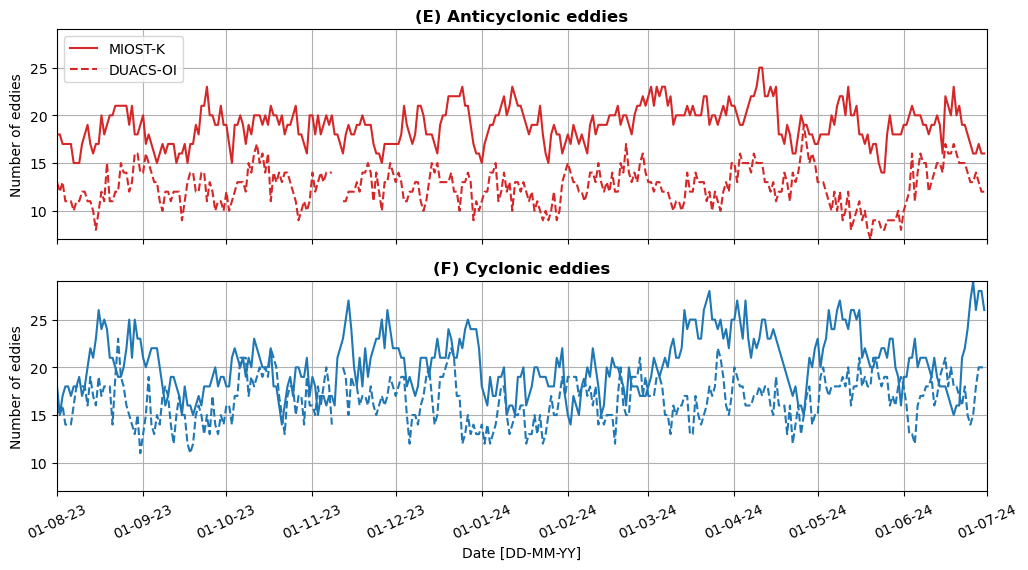

In [22]:
plt.figure(figsize=(12,6))
ax1=plt.subplot(211)
plt.plot(ndates, nb_a_m_v201, 'C3', label='MIOST-K') 
plt.plot(ndates, nb_a_d, '--', c='C3', label='DUACS-OI') 
plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Rotate date labels for better readability
plt.xticks(rotation=45)
ax1.tick_params(labelbottom=False) # Hide them

plt.ylabel("Number of eddies")
plt.title("(E) Anticyclonic eddies", fontweight='bold')
plt.legend(loc=2)
plt.ylim([7, 29])
ax1.set_xlim(datetime(2023, 8, 1), datetime(2024, 7, 1))


ax1=plt.subplot(212)
plt.plot(ndates, nb_c_m_v201, 'C0', label='MIOST-K') 
plt.plot(ndates, nb_c_d, '--', c= 'C0', label='DUACS-OI') 

plt.grid()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))

# Rotate date labels for better readability
plt.xticks(rotation=25)

plt.xlabel("Date [DD-MM-YY]")
plt.ylabel("Number of eddies")
plt.title("(F) Cyclonic eddies", fontweight='bold')
plt.ylim([7, 29])
ax1.set_xlim(datetime(2023, 8, 1), datetime(2024, 7, 1))

plt.savefig("figures/fig2e-f.png", dpi=300, bbox_inches="tight")


## Find days: (Looking for days where negative, i.e. higher number for DUACS than MIOST)

### v.2.0.1

In [23]:
inds_a_v201 = np.where((nb_a_m_v201 - nb_a_d) < 0)[0]
ndates_a_v201 = [ndates[ii] for ii in inds_a_v201]
ndates_a_v201
# if later than july, august, sept, oct 2024 we get lower value (bad data, coming from the CMEMS data)

[]

In [24]:
inds_c_v201 = np.where((nb_c_m_v201 - nb_c_d) < 0)[0]
ndates_c_v201 = [ndates[ii] for ii in inds_c_v201]
ndates_c_v201

[datetime.datetime(2023, 8, 10, 0, 0),
 datetime.datetime(2023, 8, 23, 0, 0),
 datetime.datetime(2023, 9, 9, 0, 0),
 datetime.datetime(2023, 10, 6, 0, 0),
 datetime.datetime(2023, 10, 8, 0, 0),
 datetime.datetime(2023, 10, 18, 0, 0),
 datetime.datetime(2023, 10, 19, 0, 0),
 datetime.datetime(2023, 10, 20, 0, 0),
 datetime.datetime(2023, 10, 21, 0, 0),
 datetime.datetime(2023, 10, 25, 0, 0),
 datetime.datetime(2023, 11, 3, 0, 0),
 datetime.datetime(2023, 11, 5, 0, 0),
 datetime.datetime(2023, 11, 6, 0, 0),
 datetime.datetime(2023, 11, 7, 0, 0),
 datetime.datetime(2023, 12, 13, 0, 0),
 datetime.datetime(2024, 2, 1, 0, 0),
 datetime.datetime(2024, 2, 2, 0, 0),
 datetime.datetime(2024, 2, 3, 0, 0),
 datetime.datetime(2024, 2, 4, 0, 0),
 datetime.datetime(2024, 2, 5, 0, 0),
 datetime.datetime(2024, 2, 7, 0, 0),
 datetime.datetime(2024, 2, 20, 0, 0),
 datetime.datetime(2024, 2, 24, 0, 0),
 datetime.datetime(2024, 2, 25, 0, 0),
 datetime.datetime(2024, 2, 26, 0, 0),
 datetime.datetime(2024, 2

**--> mostly february and also october 23!**

# Stats.:

In [25]:
print('Mean: ', f"{np.mean(nb_a_m_v201):.1f}")
print('STD: ', f"{np.std(nb_a_m_v201):.1f}")
print('Min: ', f"{np.nanmin(nb_a_m_v201):.1f}")
print('Max: ', f"{np.nanmax(nb_a_m_v201):.1f}")
print('Range: ', f"{np.nanmax(nb_a_m_v201)-np.nanmin(nb_a_m_v201):.1f}")

Mean:  19.0
STD:  2.0
Min:  14.0
Max:  25.0
Range:  11.0


In [26]:
print('Mean: ', f"{np.nanmean(nb_a_d):.1f}")
print('STD: ', f"{np.nanstd(nb_a_d):.1f}")
print('Min: ', f"{np.nanmin(nb_a_d):.1f}")
print('Max: ', f"{np.nanmax(nb_a_d):.1f}")
print('Range: ', f"{np.nanmax(nb_a_d)-np.nanmin(nb_a_d):.1f}")

Mean:  12.5
STD:  2.0
Min:  7.0
Max:  19.0
Range:  12.0


In [27]:
print('Mean: ', f"{np.mean(nb_c_m_v201):.1f}")
print('STD: ', f"{np.std(nb_c_m_v201):.1f}")
print('Min: ', f"{np.nanmin(nb_c_m_v201):.1f}")
print('Max: ', f"{np.nanmax(nb_c_m_v201):.1f}")
print('Range: ', f"{np.nanmax(nb_c_m_v201)-np.nanmin(nb_c_m_v201):.1f}")

Mean:  20.4
STD:  3.1
Min:  14.0
Max:  29.0
Range:  15.0


In [28]:
print('Mean: ', f"{np.nanmean(nb_c_d):.1f}")
print('STD: ', f"{np.nanstd(nb_c_d):.1f}")
print('Min: ', f"{np.nanmin(nb_c_d):.1f}")
print('Max: ', f"{np.nanmax(nb_c_d):.1f}")
print('Range: ', f"{np.nanmax(nb_c_d)-np.nanmin(nb_c_d):.1f}")

Mean:  16.6
STD:  2.4
Min:  11.0
Max:  23.0
Range:  12.0


In [29]:
print('Mean diff. (M-D): ', f"{np.nanmean(nb_a_m_v201-nb_a_d):.1f}")

Mean diff. (M-D):  6.5


In [30]:
print('Mean diff. (M-D): ', f"{np.nanmean(nb_c_m_v201-nb_c_d):.1f}")

Mean diff. (M-D):  3.8


# Correlation between the 2 timeseries:

In [31]:
# Example
ts1 = nb_a_m_v201
ts2 = nb_a_d

# Keep only valid values
mask = ~np.isnan(ts1) & ~np.isnan(ts2)

corr_a = np.corrcoef(ts1[mask], ts2[mask])[0, 1]

print(f"Correlation: {corr_a:.3f}")

Correlation: 0.253


## Cyclones correlation:

In [32]:
# Example
ts1 = nb_c_m_v201
ts2 = nb_c_d

# Keep only valid values
mask = ~np.isnan(ts1) & ~np.isnan(ts2)

corr_c = np.corrcoef(ts1[mask], ts2[mask])[0, 1]

print(f"Correlation: {corr_c:.3f}")

Correlation: 0.165


# Numpy correlation explanation:

np.corrcoef() uses the Pearson correlation coefficient.

Mathematically:

$r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}$

It measures the linear relationship between two variables:

r = 1 → perfect positive linear relationship
r = -1 → perfect negative linear relationship
r = 0 → no linear relationship

Numpy calculates: 
```
cov(x, y) / (std(x) * std(y))
```